---
# Trabalho 2
---
---

**Nome**: Brithany Michelle Oliva Chuquimia

**Matrícula**: 971


In [11]:
import numpy as np
import math
import matplotlib.pyplot as plt

# 1) Convergência e Lei dos Grandes Números

Considere a estimativa da integral:

 I = ∫ (0 a 1) (ln(1+x)dx)

    a) Estime I usando Monte Carlo com amostragem uniforme.
    b) Execute simulações com N = 10², 10³, 10⁴, 10⁵
    c) Plote o erro absoluto em função de N.

N = 100
Estimativa = 0.37570678668577473
Erro absoluto = 0.010587574434115843

N = 1000
Estimativa = 0.3881986308583548
Erro absoluto = 0.0019042697384642482

N = 10000
Estimativa = 0.38555707394536987
Erro absoluto = 0.0007372871745207066

N = 100000
Estimativa = 0.38592467020223487
Erro absoluto = 0.0003696909176557073



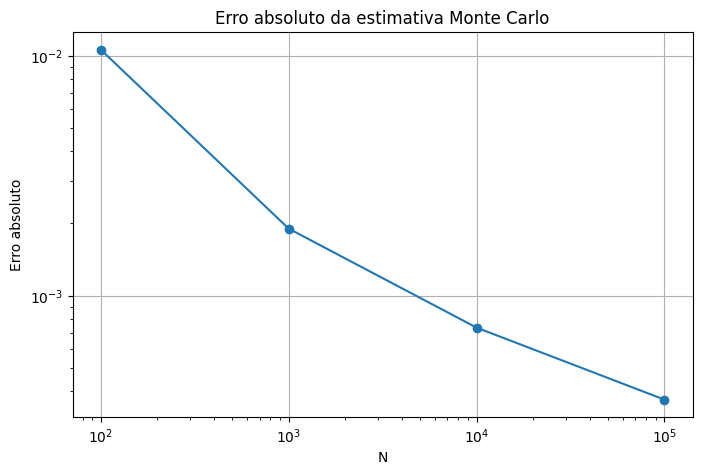

In [12]:
# Fixar a semente
np.random.seed(1)

# Valor teórico
I_teorico = 2 * np.log(2) - 1

# Tamanhos de amostra pedidos
Ns = [10**2, 10**3, 10**4, 10**5]

estimativas = []
erros = []

for N in Ns:
    # Gerar N amostras uniformes em [0,1]
    u = np.random.uniform(0, 1, N)

    # Calcular g(u) = ln(1+u)
    valores = np.log(1 + u)

    # Estimativa Monte Carlo
    I_hat = np.mean(valores)

    # Erro absoluto
    erro = abs(I_hat - I_teorico)

    estimativas.append(I_hat)
    erros.append(erro)

    print(f"N = {N}")
    print("Estimativa =", I_hat)
    print("Erro absoluto =", erro)
    print()

# Gráfico do erro absoluto
plt.figure(figsize=(8,5))
plt.plot(Ns, erros, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("N")
plt.ylabel("Erro absoluto")
plt.title("Erro absoluto da estimativa Monte Carlo")
plt.grid(True)
plt.show()

# 2) Importance Sampling

Considere:

 I = ∫ (0 a 1) ((1/(1+x)^2)dx)

    a) Estime via Monte Carlo simples, usando a uniforme.
    b) Escolha uma distribuição p(x).
    c) Reescreva o estimador e calcule a integral.
    d) Compare os métodos.
    e) Justifique a escolha de p(x).
    

(a) Monte Carlo simples
Estimativa = 0.5002482966729717
Erro absoluto = 0.0002482966729716596

(c) Importance Sampling
Estimativa = 0.5
Erro absoluto = 0.0

(d) Comparação
Monte Carlo simples  = 0.5002482966729717
Importance Sampling  = 0.5
Erro MC simples      = 0.0002482966729716596
Erro Importance      = 0.0
Variância MC simples = 0.041638863947213285
Variância Importance = 0.0


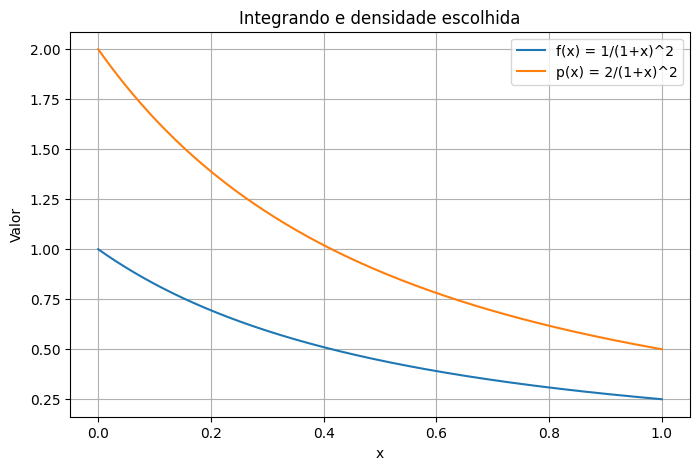

In [13]:
# Fixar a semente para que os resultados possam ser reproduzidos
np.random.seed(42)

# Definir o número de simulações
N = 100000

# Definir o valor teórico da integral
# Neste caso, o valor analítico é 0.5
I_teorico = 0.5

# -----------------------------------
# (a) Monte Carlo simples com uniforme
# -----------------------------------

# Gerar N amostras uniformes no intervalo [0,1]
u_mc = np.random.uniform(0, 1, N)

# Calcular o valor do integrando f(x) = 1/(1+x)^2
# para cada amostra gerada
f_mc = 1 / (1 + u_mc)**2

# Calcular a estimativa da integral usando a média dos valores
I_mc = np.mean(f_mc)

# Calcular o erro absoluto em relação ao valor teórico
erro_mc = abs(I_mc - I_teorico)

# Mostrar os resultados do método de Monte Carlo simples
print("(a) Monte Carlo simples")
print("Estimativa =", I_mc)
print("Erro absoluto =", erro_mc)
print()

# -----------------------------------
# (c) Importance Sampling
# p(x) = 2/(1+x)^2
# CDF: F(x) = 2 - 2/(1+x)
# Inversa: x = 2/(2-u) - 1
# -----------------------------------

# Gerar N amostras uniformes no intervalo [0,1]
u_is = np.random.uniform(0, 1, N)

# Aplicar a inversa da CDF para gerar amostras com a densidade p(x)
x_is = 2 / (2 - u_is) - 1

# Calcular o valor do integrando f(x) nas amostras geradas
f_is = 1 / (1 + x_is)**2

# Calcular o valor da densidade escolhida p(x) nas amostras geradas
p_is = 2 / (1 + x_is)**2

# Calcular os pesos do importance sampling: f(x)/p(x)
pesos = f_is / p_is

# Calcular a estimativa da integral pela média dos pesos
I_is = np.mean(pesos)

# Calcular o erro absoluto em relação ao valor teórico
erro_is = abs(I_is - I_teorico)

# Mostrar os resultados do método de importance sampling
print("(c) Importance Sampling")
print("Estimativa =", I_is)
print("Erro absoluto =", erro_is)
print()

# -----------------------------------
# (d) Comparação dos métodos
# -----------------------------------

# Mostrar lado a lado os resultados dos dois métodos
print("(d) Comparação")
print("Monte Carlo simples  =", I_mc)
print("Importance Sampling  =", I_is)
print("Erro MC simples      =", erro_mc)
print("Erro Importance      =", erro_is)
print("Variância MC simples =", np.var(f_mc))
print("Variância Importance =", np.var(pesos))

# -----------------------------------
# Gráfico do integrando e da densidade escolhida
# -----------------------------------

# Criar valores de x no intervalo [0,1] para desenhar as curvas
x = np.linspace(0, 1, 400)

# Calcular o integrando f(x)
f = 1 / (1 + x)**2

# Calcular a densidade escolhida p(x)
p = 2 / (1 + x)**2

# Criar a figura
plt.figure(figsize=(8,5))

# Plotar o integrando
plt.plot(x, f, label='f(x) = 1/(1+x)^2')

# Plotar a densidade usada no importance sampling
plt.plot(x, p, label='p(x) = 2/(1+x)^2')

# Adicionar título e rótulos aos eixos
plt.title("Integrando e densidade escolhida")
plt.xlabel("x")
plt.ylabel("Valor")

# Mostrar a legenda
plt.legend()

# Adicionar grade
plt.grid(True)

# Mostrar o gráfico
plt.show()

# 3) Aceitação-Rejeição

Deseja-se gerar amostras de

f(x)=3x^2,  x∈[0,1]

    a) Implemente aceitação-rejeição.
    b) Calcule taxa de aceitação.
    c) Compare com método da inversa.
    d) Discuta eficiência.

In [14]:
# Fixar a semente para que os resultados possam ser reproduzidos
np.random.seed(42)

# Definir o número de amostras que queremos gerar
N = 10000

# -----------------------------------
# (a) Implementar aceitação-rejeição
# -----------------------------------

# Criar uma lista vazia para armazenar as amostras aceitas
amostras_ar = []

# Inicializar o contador do número total de tentativas
tentativas = 0

# Repetir o processo até obter N amostras aceitas
while len(amostras_ar) < N:

    # Gerar uma proposta y com distribuição uniforme no intervalo [0,1]
    y = np.random.uniform(0, 1)

    # Gerar uma segunda variável uniforme auxiliar
    # que será usada no teste de aceitação
    u = np.random.uniform(0, 1)

    # Incrementar o número total de tentativas
    tentativas += 1

    # Aceitar a amostra se u <= y^2
    # Isso vem do critério de aceitação:
    # u <= f(y) / (M * g(y))
    # Neste problema, esse critério se reduz a u <= y^2
    if u <= y**2:
        amostras_ar.append(y)

# Converter a lista de amostras aceitas em array do NumPy
amostras_ar = np.array(amostras_ar)

# -----------------------------------
# (b) Taxa de aceitação
# -----------------------------------

# Calcular a taxa de aceitação como:
# número de amostras aceitas / número total de tentativas
taxa_aceitacao = N / tentativas

# Mostrar a taxa de aceitação obtida
print("(b) Taxa de aceitação =", taxa_aceitacao)

# -----------------------------------
# (c) Comparar com método da inversa
# F(x)=x^3  =>  X = U^(1/3)
# -----------------------------------

# Gerar N valores uniformes no intervalo [0,1]
u_inv = np.random.uniform(0, 1, N)

# Aplicar a inversa da CDF:
# X = U^(1/3)
amostras_inv = u_inv**(1/3)

# Comparar média e variância das amostras geradas
# pelos dois métodos
print("(c) Média A-R     =", np.mean(amostras_ar))
print("    Média inversa =", np.mean(amostras_inv))
print("    Var A-R       =", np.var(amostras_ar))
print("    Var inversa   =", np.var(amostras_inv))

(b) Taxa de aceitação = 0.3310162197947699
(c) Média A-R     = 0.7505555003180024
    Média inversa = 0.7511291021846952
    Var A-R       = 0.03673773417790055
    Var inversa   = 0.03736932943167204


# 4) Simulação Monte Carlo

Uma caixa contém 48 cartas, distribuídas igualmente em 4 tipos:

* 12 cartas do tipo A
* 12 cartas do tipo B
* 12 cartas do tipo C
* 12 cartas do tipo D

São retiradas 7 cartas aleatoriamente sem reposição.

    a) Qual é a probabilidade de obter pelo menos uma carta do tipo B e uma do tipo D?
    b) Refaça o cálculo supondo que as cartas sejam retiradas com reposição
    c) Explique qualitativamente a diferença entre os dois resultados

In [15]:
# Fixar a semente para que os resultados possam ser reproduzidos
np.random.seed(42)

# Definir o número de simulações que serão realizadas
N = 100000

# Construir a caixa com as 48 cartas
# 12 cartas do tipo A
# 12 cartas do tipo B
# 12 cartas do tipo C
# 12 cartas do tipo D
cartas = ['A']*12 + ['B']*12 + ['C']*12 + ['D']*12

# -----------------------------------
# (a) Sem reposição
# -----------------------------------

# Inicializar o contador de sucessos para o caso sem reposição
sucessos_sem = 0

# Repetir o experimento N vezes
for _ in range(N):

    # Sortear 7 cartas sem reposição
    amostra = np.random.choice(cartas, size=7, replace=False)

    # Verificar se na amostra há pelo menos uma carta do tipo B
    # e pelo menos uma carta do tipo D
    if ('B' in amostra) and ('D' in amostra):
        sucessos_sem += 1

# Estimar a probabilidade pela frequência relativa
prob_sem = sucessos_sem / N

# Mostrar o resultado do item (a)
print("(a) Sem reposição")
print("Probabilidade estimada =", prob_sem)

# -----------------------------------
# (b) Com reposição
# -----------------------------------

# Inicializar o contador de sucessos para o caso com reposição
sucessos_com = 0

# Repetir o experimento N vezes
for _ in range(N):

    # Sortear 7 cartas com reposição
    amostra = np.random.choice(cartas, size=7, replace=True)

    # Verificar se na amostra há pelo menos uma carta do tipo B
    # e pelo menos uma carta do tipo D
    if ('B' in amostra) and ('D' in amostra):
        sucessos_com += 1

# Estimar a probabilidade pela frequência relativa
prob_com = sucessos_com / N

# Mostrar o resultado do item (b)
print("\n(b) Com reposição")
print("Probabilidade estimada =", prob_com)

# -----------------------------------
# (c) Comparação qualitativa
# -----------------------------------

# Mostrar os dois valores estimados para comparar
print("\n(c) Comparação qualitativa")
print("Sem reposição =", prob_sem)
print("Com reposição =", prob_com)

(a) Sem reposição
Probabilidade estimada = 0.77685

(b) Com reposição
Probabilidade estimada = 0.74136

(c) Comparação qualitativa
Sem reposição = 0.77685
Com reposição = 0.74136


# 5) Simulação Monte Carlo

Considere o lançamento simultâneo de dois dados equilibrados.

    a) Utilize simulação de Monte Carlo para estimar a probabilidade de que a soma dos resultados seja estritamente maior que 9
    b) Compare o valor obtido com o valor teórico
    c) Discuta como o número de simulações afeta a precisão do resultado

(a) Probabilidade simulada = 0.16635

(b) Comparação com o valor teórico
Valor teórico = 0.16666666666666666
Valor simulado = 0.16635
Erro absoluto = 0.00031666666666665955
N = 100, estimativa = 0.2, erro = 0.033333333333333354
N = 1000, estimativa = 0.168, erro = 0.001333333333333353
N = 10000, estimativa = 0.1667, erro = 3.333333333332966e-05
N = 100000, estimativa = 0.16776, erro = 0.001093333333333335


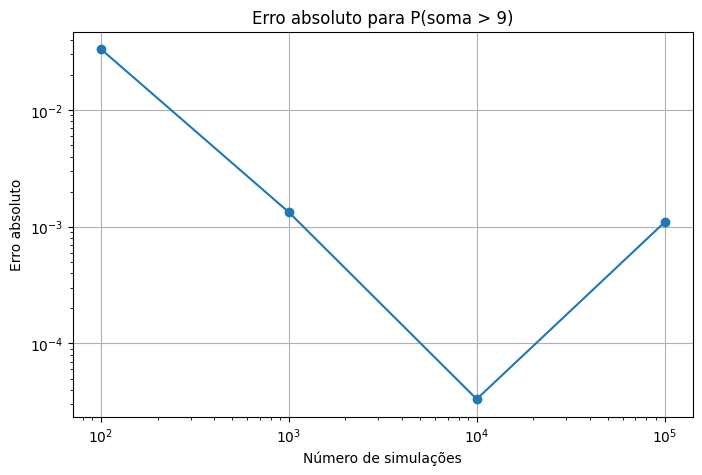

In [16]:
# Fixar a semente para que os resultados possam ser reproduzidos
np.random.seed(42)

# Definir o valor teórico da probabilidade
# A probabilidade de a soma de dois dados ser maior que 9 é 1/6
p_teorico = 1/6

# -----------------------------------
# (a) Estimar por Monte Carlo
# -----------------------------------

# Definir o número de simulações
N = 100000

# Gerar N resultados para o primeiro dado
dado1 = np.random.randint(1, 7, N)

# Gerar N resultados para o segundo dado
dado2 = np.random.randint(1, 7, N)

# Calcular a soma dos resultados dos dois dados
soma = dado1 + dado2

# Estimar a probabilidade de a soma ser maior que 9
# usando a frequência relativa
p_sim = np.mean(soma > 9)

# Mostrar o resultado do item (a)
print("(a) Probabilidade simulada =", p_sim)

# -----------------------------------
# (b) Comparar com valor teórico
# -----------------------------------

# Calcular o erro absoluto entre o valor simulado e o valor teórico
erro = abs(p_sim - p_teorico)

# Mostrar a comparação entre os valores
print("\n(b) Comparação com o valor teórico")
print("Valor teórico =", p_teorico)
print("Valor simulado =", p_sim)
print("Erro absoluto =", erro)

# -----------------------------------
# (c) Efeito do número de simulações
# -----------------------------------

# Definir diferentes quantidades de simulações
Ns = [10**2, 10**3, 10**4, 10**5]

# Criar uma lista vazia para armazenar os erros absolutos
erros = []

# Repetir o experimento para diferentes valores de N
for N_sim in Ns:

    # Gerar resultados para os dois dados
    d1 = np.random.randint(1, 7, N_sim)
    d2 = np.random.randint(1, 7, N_sim)

    # Calcular a soma
    soma = d1 + d2

    # Calcular a estimativa da probabilidade
    p_hat = np.mean(soma > 9)

    # Calcular o erro absoluto
    erro_hat = abs(p_hat - p_teorico)

    # Armazenar o erro na lista
    erros.append(erro_hat)

    # Mostrar os resultados para cada N
    print(f"N = {N_sim}, estimativa = {p_hat}, erro = {erro_hat}")

# Criar o gráfico do erro absoluto em função do número de simulações
plt.figure(figsize=(8,5))
plt.plot(Ns, erros, marker='o')

# Colocar os eixos em escala logarítmica
plt.xscale('log')
plt.yscale('log')

# Adicionar rótulos e título
plt.xlabel("Número de simulações")
plt.ylabel("Erro absoluto")
plt.title("Erro absoluto para P(soma > 9)")

# Adicionar grade
plt.grid(True)

# Mostrar o gráfico
plt.show()